# External Engine Parity: ml4t-backtest vs LEAN

**Docker image**: `ml4t`

This notebook extends the Chapter 16 parity discussion from internal engine
semantics to an external benchmark: QuantConnect LEAN. The goal is to show
how `ml4t-backtest` is configured to reproduce an external engine and how
that claim is verified on a canonical benchmark.

**Learning Objectives**:
- Inspect the canonical LEAN parity benchmark used by `ml4t-backtest`
- Compare fill count, final value, and runtime between LEAN and `ml4t-lean`
- Understand which execution/account rules are required to match LEAN
- Re-run the benchmark locally when Docker and `lean init` are available

**Book Reference**: Chapter 16, Section 16.3 (Vectorized and Event-Driven Backtesting)

**Prerequisites**: `06_framework_parity` and `07_engine_divergence_anatomy`

## Setup

In [1]:
"""External engine parity benchmark for ml4t-backtest and QuantConnect LEAN."""

import json
import shutil
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import ml4t.backtest as ml4t_backtest_pkg
import polars as pl

from utils.paths import get_chapter_dir, get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides after this cell
RUN_LIVE = False
SCENARIO_ID = "multi_250_20yr"
REAL_DATA_PATH = ""

In [3]:
OUTPUT_DIR = get_output_dir(16, "lean_engine_parity")
CACHED_ARTIFACT_PATH = get_chapter_dir(16) / "resources" / "lean_parity_results.json"
LIVE_ARTIFACT_PATH = OUTPUT_DIR / "lean_parity_results_live.json"

## 1. Source of Truth

The LEAN workflow used by `ml4t-backtest` lives in the library validation
harness, not in the earlier static scenario scaffolding.

This notebook therefore uses:

1. a committed cached artifact for deterministic execution by default
2. an optional live rerun through `validation/benchmark_suite.py`

The current LEAN adapter now persists fill logs, order events, equity traces,
and a symbol map. That lets the validation harness compare real fill
chronology rather than relying on headline summary counts alone.

### Resolve the sibling `ml4t-backtest` repository

We infer the repository root from the installed package rather than
hardcoding a machine-specific path.

In [4]:
def resolve_backtest_repo() -> Path | None:
    """Resolve the sibling ml4t-backtest repository root.

    Returns None when the validation harness is not available (e.g. CI),
    which disables the live rerun path but lets the cached artifact work.
    """
    package_path = Path(ml4t_backtest_pkg.__file__).resolve()
    for parent in package_path.parents:
        if (parent / "validation" / "benchmark_suite.py").exists():
            return parent

    fallback = Path.home() / "ml4t" / "libraries" / "ml4t-backtest"
    if (fallback / "validation" / "benchmark_suite.py").exists():
        return fallback

    return None


BACKTEST_REPO = resolve_backtest_repo()
BENCHMARK_SUITE = BACKTEST_REPO / "validation" / "benchmark_suite.py" if BACKTEST_REPO else None
LEAN_README = BACKTEST_REPO / "validation" / "lean" / "README.md" if BACKTEST_REPO else None

print(f"Backtest repo:   {BACKTEST_REPO or 'not found (cached artifact only)'}")
print(f"Benchmark suite: {BENCHMARK_SUITE or 'not found'}")
print(f"LEAN workflow:   {LEAN_README or 'not found'}")

Backtest repo:   ~/ml4t/libraries/ml4t-backtest
Benchmark suite: ~/ml4t/libraries/ml4t-backtest/validation/benchmark_suite.py
LEAN workflow:   ~/ml4t/libraries/ml4t-backtest/validation/lean/README.md


## 2. Runtime Prerequisites

A live rerun requires more than Python imports. The benchmark harness needs:

- Docker
- `lean` or `uvx`
- a machine-local `validation/lean/workspace/lean.json`
- the real daily equity parquet used for the parity run

### Locate the real-data parquet

The notebook accepts an explicit parameter override, but otherwise searches a
small set of likely locations without depending on a single hardcoded path.

In [5]:
def find_real_data_path(explicit_path: str) -> Path | None:
    """Locate the real daily equity parquet used by the benchmark harness."""
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path).expanduser())

    env_path = Path.home() / "Dropbox" / "ml4t" / "data" / "equities" / "us_equities.parquet"
    candidates.append(env_path)

    for path in candidates:
        if path.exists():
            return path
    return None


REAL_DATA_FILE = find_real_data_path(REAL_DATA_PATH)
print(f"Real data parquet: {REAL_DATA_FILE if REAL_DATA_FILE else 'not found'}")

Real data parquet: not found


### Check live-run readiness

The cached artifact path should always work. The live path only runs when all
operational prerequisites are present.

In [6]:
def check_live_prerequisites(repo_root: Path | None, real_data_path: Path | None) -> pl.DataFrame:
    """Return a checklist for the optional live LEAN rerun."""
    lean_config = (
        repo_root / "validation" / "lean" / "workspace" / "lean.json" if repo_root else None
    )

    rows = [
        {
            "requirement": "benchmark_suite.py",
            "ready": BENCHMARK_SUITE is not None and BENCHMARK_SUITE.exists(),
            "detail": BENCHMARK_SUITE.as_posix() if BENCHMARK_SUITE else "not found",
        },
        {
            "requirement": "docker",
            "ready": shutil.which("docker") is not None,
            "detail": shutil.which("docker") or "missing",
        },
        {
            "requirement": "lean or uvx",
            "ready": shutil.which("lean") is not None or shutil.which("uvx") is not None,
            "detail": shutil.which("lean") or shutil.which("uvx") or "missing",
        },
        {
            "requirement": "lean workspace config",
            "ready": lean_config is not None and lean_config.exists(),
            "detail": lean_config.as_posix() if lean_config else "not found",
        },
        {
            "requirement": "real daily parquet",
            "ready": real_data_path is not None,
            "detail": real_data_path.as_posix() if real_data_path else "not found",
        },
    ]
    return pl.DataFrame(rows)


prereq_df = check_live_prerequisites(BACKTEST_REPO, REAL_DATA_FILE)
prereq_df

requirement,ready,detail
str,bool,str
"""benchmark_suite.py""",true,"""~/ml4t/libraries/ml…"
"""docker""",true,"""/usr/local/bin/docker"""
"""lean or uvx""",true,""".venv/b…"
"""lean workspace config""",true,"""~/ml4t/libraries/ml…"
"""real daily parquet""",false,"""not found"""


## 3. Load the Cached Parity Artifact

The committed artifact captures the real-data 250-asset, 20-year benchmark
comparison cited in the parity analysis:

$$\Delta_{trades} = \frac{N_{ml4t} - N_{LEAN}}{N_{LEAN}}$$

$$\Delta_{value} = \frac{V_{ml4t} - V_{LEAN}}{V_{LEAN}}$$

By default the notebook reads this snapshot so it remains useful on machines
that do not have LEAN bootstrapped locally.

In [7]:
def load_parity_artifact(path: Path) -> dict:
    """Load a cached parity artifact."""
    return json.loads(path.read_text(encoding="utf-8"))


payload = load_parity_artifact(CACHED_ARTIFACT_PATH)
payload["scenario_label"], payload["artifact_source"]

('250 assets, 20 years daily',
 'benchmark_suite.py real-data rerun (250 US equities x 20yr daily, 1998-2018)')

### Optional live rerun

When `RUN_LIVE = True` and the prerequisite table is fully green, the notebook
reruns the benchmark harness for:

- `ml4t-lean`
- `lean`

and writes a notebook-local artifact alongside the cached snapshot.

### Execute one framework through the benchmark harness

The harness writes a standard JSON report. We run each framework separately
and then merge the two results into one notebook-friendly payload.

In [8]:
def run_framework_benchmark(
    framework: str, scenario_id: str, output_path: Path, real_data_path: Path
) -> dict:
    """Run one benchmark-suite framework and return its single result row."""
    cmd = [
        sys.executable,
        str(BENCHMARK_SUITE),
        "--framework",
        framework,
        "--scenario",
        scenario_id,
        "--data-source",
        "real",
        "--real-data-path",
        str(real_data_path),
        "--output-json",
        str(output_path),
    ]
    subprocess.run(cmd, check=True, cwd=str(BACKTEST_REPO))
    report = json.loads(output_path.read_text(encoding="utf-8"))
    return report["results"][0]

### Merge the live benchmark results

This normalizes the benchmark-suite output into the same shape as the cached
artifact so the comparison cells below can treat both paths identically.

In [9]:
def build_live_payload(ml4t_result: dict, lean_result: dict, scenario_id: str) -> dict:
    """Build the notebook payload from two live benchmark results."""
    trade_gap = int(ml4t_result["num_trades"] - lean_result["num_trades"])
    value_gap = float(ml4t_result["final_value"] - lean_result["final_value"])
    lean_trades = max(int(lean_result["num_trades"]), 1)
    lean_value = max(float(lean_result["final_value"]), 1.0)
    runtime_speedup = (
        float(lean_result["runtime_sec"]) / float(ml4t_result["runtime_sec"])
        if ml4t_result["runtime_sec"] > 0
        else None
    )

    return {
        "artifact_source": "live benchmark_suite.py rerun",
        "scenario_id": scenario_id,
        "scenario_label": ml4t_result["scenario"],
        "data_source": "real",
        "cached": False,
        "limitations": [
            "Parity is evaluated on decoded fill-level chronology plus final portfolio value.",
            "LEAN's summary trade count remains an aggregate order statistic; fill count is the parity surface.",
        ],
        "results": [
            {
                "framework_id": "ml4t-lean",
                "label": "ml4t-backtest (LEAN profile)",
                "num_trades": int(ml4t_result["num_trades"]),
                "final_value": float(ml4t_result["final_value"]),
                "runtime_sec": float(ml4t_result["runtime_sec"]),
                "data_points": int(ml4t_result["data_points"]),
            },
            {
                "framework_id": "lean",
                "label": "QuantConnect LEAN CLI",
                "num_trades": int(lean_result["num_trades"]),
                "final_value": float(lean_result["final_value"]),
                "runtime_sec": float(lean_result["runtime_sec"]),
                "data_points": int(lean_result["data_points"]),
            },
        ],
        "comparison": {
            "trade_gap": trade_gap,
            "trade_gap_pct": trade_gap / lean_trades,
            "final_value_gap": value_gap,
            "final_value_gap_pct": value_gap / lean_value,
            "runtime_speedup": runtime_speedup,
            "remaining_gap_driver": "price_precision",
            "notes": [
                "next-bar open execution is aligned",
                "margin-enabled LEAN account semantics are aligned",
                "decoded fill chronology matches exactly at event identity and 4-decimal price",
            ],
        },
    }

In [10]:
ready_for_live = bool(prereq_df["ready"].all())
if RUN_LIVE and ready_for_live and REAL_DATA_FILE is not None:
    ml4t_json = OUTPUT_DIR / "ml4t_lean_live.json"
    lean_json = OUTPUT_DIR / "lean_live.json"

    ml4t_result = run_framework_benchmark(
        "ml4t-lean",
        SCENARIO_ID,
        ml4t_json,
        REAL_DATA_FILE,
    )
    lean_result = run_framework_benchmark(
        "lean",
        SCENARIO_ID,
        lean_json,
        REAL_DATA_FILE,
    )
    payload = build_live_payload(ml4t_result, lean_result, SCENARIO_ID)
    LIVE_ARTIFACT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved live artifact: {LIVE_ARTIFACT_PATH}")
elif RUN_LIVE and not ready_for_live:
    print("Live rerun requested, but prerequisites are incomplete. Using cached artifact instead.")
else:
    print("Using cached parity artifact.")

Using cached parity artifact.


## 4. Build the Comparison Table

The benchmark scenario is the real-data validation harness, not the ten-ETF
chapter baseline:

- 250 US equities
- 20 years of daily bars
- top-25 / bottom-25 canonical target-share portfolio
- LEAN compared against `ml4t-lean`

In [11]:
comparison_df = pl.DataFrame(payload["results"]).with_columns(
    (pl.col("runtime_sec") / 60).round(2).alias("runtime_min"),
    ((pl.col("data_points") / pl.col("runtime_sec")).round(0)).alias("bars_per_sec"),
    (pl.col("final_value") - 1_000_000).alias("pnl"),
)
comparison_df

framework_id,label,num_trades,final_value,runtime_sec,data_points,runtime_min,bars_per_sec,pnl
str,str,i64,f64,f64,i64,f64,f64,f64
"""ml4t-lean""","""ml4t-backtest (LEAN profile)""",428459,720044.000482,41.654059,1260000,0.69,30249.0,-279955.999518
"""lean""","""QuantConnect LEAN CLI""",428459,720042.43,188.393125,1260000,3.14,6688.0,-279957.57


### Gap summary

The benchmark is close enough to treat parity as operationally complete for
this validation surface.

In [12]:
comparison = payload["comparison"]

print(f"Scenario:            {payload['scenario_label']}")
print(f"Artifact source:     {payload['artifact_source']}")
print(f"Trade gap:           {comparison['trade_gap']:,} ({comparison['trade_gap_pct']:.2%})")
print(
    f"Final value gap:     ${comparison['final_value_gap']:,.2f} "
    f"({comparison['final_value_gap_pct'] * 10_000:.4f} bps)"
)
print(f"Runtime speedup:     {comparison['runtime_speedup']:.2f}x")
print(f"Remaining driver:    {comparison['remaining_gap_driver']}")

Scenario:            250 assets, 20 years daily
Artifact source:     benchmark_suite.py real-data rerun (250 US equities x 20yr daily, 1998-2018)
Trade gap:           0 (0.00%)
Final value gap:     $1.57 (0.0218 bps)
Runtime speedup:     4.52x
Remaining driver:    price_precision


## 5. Visual Comparison

The chart below focuses on the three quantities the current adapter exposes
reliably: trade count, final value, and runtime.

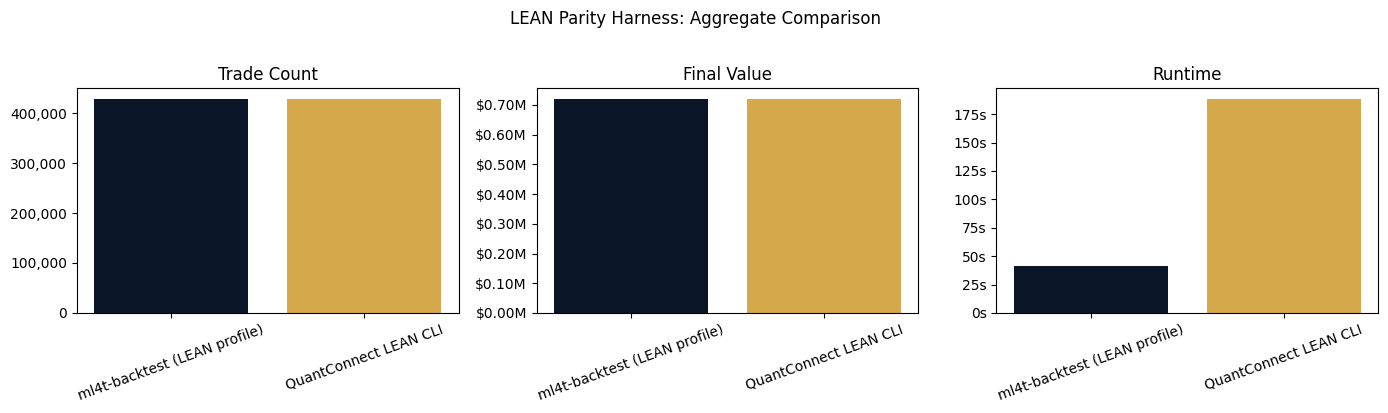

In [13]:
labels = comparison_df["label"].to_list()
trade_counts = comparison_df["num_trades"].to_list()
final_values = comparison_df["final_value"].to_list()
runtimes = comparison_df["runtime_sec"].to_list()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(labels, trade_counts, color=[COLORS["blue"], COLORS["amber"]])
axes[0].set_title("Trade Count")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].bar(labels, final_values, color=[COLORS["blue"], COLORS["amber"]])
axes[1].set_title("Final Value")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x / 1_000_000:.2f}M"))

axes[2].bar(labels, runtimes, color=[COLORS["blue"], COLORS["amber"]])
axes[2].set_title("Runtime")
axes[2].tick_params(axis="x", rotation=20)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}s"))

fig.suptitle("LEAN Parity Harness: Aggregate Comparison", y=1.02)
fig.tight_layout()
fig.show()

## 6. Interpret the Remaining Gap

The traced fill comparison identified the decisive configuration choices:

- next-bar open execution
- margin-enabled account semantics
- fill-level comparison using decoded LEAN symbols

What remains is negligible and mostly reflects price precision / mark-to-
market rounding rather than a behavioral mismatch.

In [14]:
interpretation_df = pl.DataFrame(
    {
        "aligned_knob": [
            "execution timing",
            "account model",
            "symbol decoding",
            "fill chronology",
            "remaining mismatch",
        ],
        "status": [
            "next-bar open",
            "margin enabled",
            "decoded LEAN symbols",
            "exact at event identity + 4dp",
            f"${abs(comparison['final_value_gap']):.2f} value delta",
        ],
        "impact": [
            "moved first divergence off day zero",
            "removed false short-side rejections",
            "made trade-by-trade comparison meaningful",
            "eliminated the fill gap on the canonical benchmark",
            "practically negligible",
        ],
    }
)
interpretation_df

aligned_knob,status,impact
str,str,str
"""execution timing""","""next-bar open""","""moved first divergence off day…"
"""account model""","""margin enabled""","""removed false short-side rejec…"
"""symbol decoding""","""decoded LEAN symbols""","""made trade-by-trade comparison…"
"""fill chronology""","""exact at event identity + 4dp""","""eliminated the fill gap on the…"
"""remaining mismatch""","""$1.57 value delta""","""practically negligible"""


## Key Takeaways

1. **The LEAN comparison belongs in the validation harness.** The working,
   documented source of truth is `validation/benchmark_suite.py`, not the
   legacy static LEAN scenario folder.

2. **The decisive knobs are now explicit.** LEAN daily market orders behaved
   like next-bar open fills with margin-enabled account semantics.

3. **The canonical benchmark matches at the fill surface.** The decoded LEAN
   fill log and `ml4t-backtest` record the same number of fills, and the
   final-value delta is only a few dollars on a roughly \$720K book. The gap
   summary cell above prints the exact figures from the loaded artifact.

4. **This benchmark should stay canonical.** It is the right place to prove
   external-engine equivalence before reusing the same profile in case studies.

**Next**: Return to [`07_engine_divergence_anatomy`](07_engine_divergence_anatomy.ipynb)
to map these cross-engine differences back to the execution knobs that create them.

---
*Notebook: 15_lean_engine_parity*
*ML4T 3rd Edition - Chapter 16: Strategy Simulation*